In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

In [2]:
class Quadratic(TypedDict):
  root:int
  a:int
  b:int
  c:int
  discriminant:float
  equation:str
  result:str

In [3]:
def calculate_equation(state:Quadratic):
  if(state['b']<0 and state['c']<0):
    equation=f"{state['a']}x^2{state['b']}x{state['c']}"
  elif(state['b']<0 and state['c']>0):
    equation=f"{state['a']}x^2{state['b']}x+{state['c']}"
  elif(state['b']>0 and state['c']<0):
    equation=f"{state['a']}x^2+{state['b']}x{state['c']}"
  else:
    equation=f"{state['a']}x^2+{state['b']}x+{state['c']}"
  return {'equation':equation}

In [4]:
def calculate_discriminant(state:Quadratic):
  discriminant=(state['b']**2)-(4*state['a']*state['c'])
  return {'discriminant':discriminant}

In [5]:
def real_root(state:Quadratic):
  root1=(-state['b']+(state['discriminant']**0.5))/(2*state['a'])
  root2=(-state['b']-(state['discriminant']**0.5))/(2*state['a'])
  result=f'In this equation the roots are {root1} and {root2}'
  return {'result':result}

In [6]:
def repeated_root(state:Quadratic):
  root=(-state['b'])/(2*state['a'])
  result=f'In this equation the root is {root}'
  return {'result':result}

In [7]:
def no_real_root(state:Quadratic):
  result='This equation has no real roots'
  return {'result':result}

In [8]:
def check_condition(state:Quadratic)->Literal['real_root','repeated_root','no_real_root']:
  if state['discriminant']>0:
    return 'real_root'
  elif state['discriminant']==0:
    return 'repeated_root'
  else:
    return 'no_real_root'

In [9]:
graph=StateGraph(Quadratic)
#nodes
graph.add_node("calculate_equation",calculate_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("real_root",real_root)
graph.add_node("repeated_root",repeated_root)
graph.add_node("no_real_root",no_real_root)
#edges
graph.add_edge(START,"calculate_equation")
graph.add_edge("calculate_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant",check_condition)
graph.add_edge("real_root",END)
graph.add_edge("repeated_root",END)
graph.add_edge("no_real_root",END)
workflow = graph.compile()


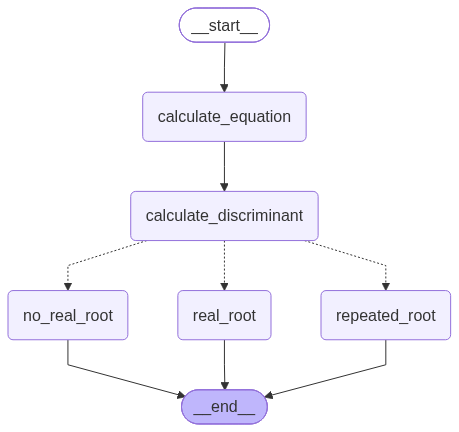

In [10]:
workflow

In [11]:
initial_state={
    'a':1,
    'b':2,
    'c':-1
}
workflow.invoke(initial_state)

{'a': 1,
 'b': 2,
 'c': -1,
 'discriminant': 8,
 'equation': '1x^2+2x-1',
 'result': 'In this equation the roots are 0.41421356237309515 and -2.414213562373095'}